### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go
from scipy.interpolate import interp1d
from scipy import integrate

### Input data:

In [2]:
mp = 41.9       #  (submerged pipe weight) [kg/m]
N = 48      # number of modelling nodes

In [3]:
qw = 1025 # Water density [kg/m3]
d0 = 0.2731 # Outer diameter of pipe, [m]
dI= (273.1-15.9*2)/1000 # Inner diameter of pipe, [m]

In [4]:
# Underwater current: 
dv1_curr = 0
dv2_curr = 0
dv3_curr = 0

In [5]:
Fx_0 = 449*1000
Fy_0 = 0.7*Fx_0
LTD = 387

In [6]:
E = 207e9
G = 79.3e9
nu=0.3

In [7]:
# vessel

In [8]:
mn = 39_989_000 # mass of the vessel, [kg]
L = 168 
Xg = 78 # [m]

In [9]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz = mn*Xg**2 + Ir
    return Iz

In [10]:
In = vessel_inertia_moment(mn, Xg, L)

In [11]:
draft = 6

In [12]:
# integration parameters
tspan = (0.,2)

### Main functions:

In [13]:
A = np.pi * ((d0/2)**2 - (dI/2)**2)

In [14]:
m = (dI/2)/ (d0/2)
m2 = m**2
k_shear = (6.0 * (1.0 + nu) * (1.0 + m2)**2) / (
    (7.0 + 6.0 * nu) * (1.0 + m2)**2 + (20.0 + 12.0 * nu) * m2)

In [15]:
A2 = k_shear * A
A3 = k_shear * A

In [16]:
J = (np.pi / 2.0) * ((d0/2)**4 - (dI/2)**4)

In [17]:
I2 = (1/12)*mp*(3*(d0/2)**2+3*(dI/2)**2+(LTD/(N-1))**2)*LTD/(N-1)
I3 = I2

In [18]:
def Πe(φ,θ,ψ):
    return np.array([[np.cos(θ),0,np.cos(φ)*np.sin(θ)],
                  [0,1,-np.sin(φ)],
                  [-np.sin(θ),0,np.cos(φ)*np.cos(θ)]])

In [19]:
def Ret_e_t(φ,θ,ψ):
    Cφ=np.array([[1,0,0],
                  [0,np.cos(φ),-np.sin(φ)],
                  [0,np.sin(φ),np.cos(φ)]])

    Cθ=np.array([[np.cos(θ),0,np.sin(θ)],
                  [0,1,0],
                  [-np.sin(θ),0,np.cos(θ)]])

    Cψ=np.array([[np.cos(ψ),-np.sin(ψ),0],
                  [np.sin(ψ),np.cos(ψ),0],
                  [0,0,1]])

    return Cθ @ Cφ @ Cψ

In [20]:
diag_J_t_rho = 1e2*np.array([1, 1, 2])      
J_t_rho = np.diag(diag_J_t_rho)

In [21]:
diag_CT = np.array([E*A, G*A2, G*A3])
CT=np.diag(diag_CT)

In [22]:
# diag_CR = np.array([G*J, E*I2, E*I3])      
diag_CR = 1e9*np.array([1, 1, 1])                     #######!!!!!!!!!!!!!!
CR=np.diag(diag_CR)

In [23]:
diag_DT = 1.5*np.array([1, 1, 1])          
DT=np.diag(diag_DT)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])            
DR=np.diag(diag_DR)

In [25]:
def I_e_rho(φ,θ,ψ):
    return Ret_e_t(φ,θ,ψ) @ J_t_rho @ Ret_e_t(φ,θ,ψ).T

In [26]:
def phi(x,y,z): return np.array([x,y,z]) 
def theta(φ,θ,ψ): return np.array([φ,θ,ψ]) 

In [27]:
def d_s_theta(φ1,θ1,ψ1,φ2,θ2,ψ2,h):
    return 1/h*(theta(φ2,θ2,ψ2) - theta(φ1,θ1,ψ1))

def omega_e(φ1,θ1,ψ1,φ2,θ2,ψ2,h):
    return Πe(φ1,θ1,ψ1) @ d_s_theta(φ1,θ1,ψ1,φ2,θ2,ψ2,h)

In [28]:
def S(a1, a2, a3 ):
    return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])

In [29]:
def d_s_phi(x1,y1,z1,x2,y2,z2, h):
    return 1/h*(phi(x2,y2,z2)-phi(x1,y1,z1))

In [30]:
def ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2,h):
    return (Ret_e_t(φ1,θ1,ψ1)@CT@Ret_e_t(φ1,θ1,ψ1).T@(d_s_phi(x1,y1,z1,x2,y2,z2,h).reshape(3,1)
            - Ret_e_t(φ1,θ1,ψ1)@np.array([1,0,0]).reshape(3,1))).reshape(1,3)

In [31]:
def me(φ1, θ1, ψ1, φ2, θ2, ψ2, h):
    return Ret_e_t(φ1,θ1,ψ1)@CR@Ret_e_t(φ1,θ1,ψ1).T@ omega_e(φ1,θ1,ψ1,φ2,θ2,ψ2,h)

In [32]:
def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([[-np.sin(θ)*dθ,0,-np.sin(φ)*dφ*np.sin(θ)+np.cos(φ)*np.cos(θ)*dθ],
                  [0,0,-np.cos(φ)*dφ],
                  [-np.cos(θ)*dθ,0,-np.sin(φ)*dφ*np.cos(θ)-np.cos(φ)*np.sin(θ)*dθ]])

In [33]:
fe_g = np.array([0,0, mp*9.81])

In [34]:
def f_t_d(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr
    A = np.array([np.abs(vr1) * vr1,
                  np.sqrt(vr2**2 + vr3**2) * vr2,
                 np.sqrt(vr2**2 + vr3**2) * vr3])
    return 0.5 * d0 * qw * (DT@ A)

In [35]:
def sigma(x,y,z):
    e3 = np.array([0,0,1])
    
    k = phi(x,y,z) @ e3+d0/2
    
    fe_g2 = np.linalg.norm(fe_g, ord=2)
   
    if k<0:
        k0=0
    elif 0<=k<=d0/20:
        k0=(fe_g2*10*k**2)/((d0/8-d0/40)*(d0))
    else:
        k0=(fe_g2*(k-d0/40))/(d0/8-d0/40)
            
    result = k0 * e3 
   
    return result  

In [36]:
def gvect(W,B,theta,phi,r_bg,r_bb):
    #     g = gvect(W,B,theta,phi,r_bg,r_bb) computes the 6x1 vector of restoring 
    #     forces about an arbitrarily point CO for a submerged body. Use 
    #     g = gRvect(W,B,R,r_bg,r_bb) if the rotation matrix R is the desired input. 
    #     For floating vessels, use Gmtrx.m.

    #     Inputs: 
    #         W, B: weight and buoyancy (N)
    #         phi,theta: roll and pitch angles (rad)
    #         r_bg = [x_g y_g z_g]: location of the CG with respect to the CO (m)
    #         r_bb = [x_b y_b z_b]: location of the CB with respect to th CO (m)

    # Thor I. Fossen

    sth  = np.sin(theta); cth  = np.cos(theta);
    sphi = np.sin(phi);   cphi = np.cos(phi);

    g = np.array([(W-B) * sth,
        -(W-B) * cth * sphi,
        -(W-B) * cth * cphi,
        -(r_bg[1]*W-r_bb[1]*B) * cth * cphi + (r_bg[2]*W-r_bb[2]*B) * cth * sphi,
         (r_bg[2]*W-r_bb[2]*B) * sth        + (r_bg[0]*W-r_bb[0]*B) * cth * cphi,
        -(r_bg[0]*W-r_bb[0]*B) * cth * sphi - (r_bg[1]*W-r_bb[1]*B) * sth       ])
    return g

In [37]:
def Hmtrx(r):
    r = np.asarray(r, dtype=float).flatten()
    H = np.eye(6)
    H[0:3, 3:6] = S(*r).T
    return H

In [38]:
def compute_damping(M_CG, G_CG, rCG, T_x,T_y,T_n):

 
    beta_z = 0.995      # w_damped = beta * w_undamped
    beta_phi = 0.995    # where beta = reduction factor
    beta_theta = 0.995
 
    v_z = 2 * np.sqrt(1 - beta_z ** 2)
    v_phi = 2 * np.sqrt(1 - beta_phi ** 2)
    v_theta = 2 * np.sqrt(1 - beta_theta ** 2)
 
    # Damping (diagonal structure at CG)
    D_CG11 = M_CG[0, 0] / T_x
    D_CG22 = M_CG[1, 1] / T_y
    D_CG66 = M_CG[5, 5] / T_n
 
    D_CG33 = v_z * np.sqrt(np.abs(M_CG[2, 2] * G_CG[ 2]))
    D_CG44 = v_phi * np.sqrt(np.abs(M_CG[3, 3] * G_CG[3]))
    D_CG55 = v_theta * np.sqrt(np.abs(M_CG[4, 4] * G_CG[4]))
 
    D_CG = np.diag([D_CG11, D_CG22, D_CG33, D_CG44, D_CG55, D_CG66])
 
    # Transform D_CG to COO
    D = Hmtrx(rCG).T @ D_CG @ Hmtrx(rCG)
 
    return D

In [39]:
def compute_added_mass_placeholder(MRB_CG, rCG, ratios=None):
    """
    Reasonable stand-in for MA when you don't yet have geometry data to run
    `compute_added_mass`, but need a plausible, positive-definite MA to
    exercise the rest of the pipeline (M, G_CG, D, eigenvalues, periods).
 
    Rather than scaling the whole MRB matrix by one constant (e.g.
    MA = 0.5*MRB), this scales each diagonal DOF of MRB_CG by a *different*,
    physically motivated ratio, since added mass/inertia does not scale
    uniformly across DOFs. Typical literature ratios for semi-submersibles/
    ships (added mass or added inertia, as a fraction of rigid-body mass or
    inertia) are used as defaults:
 
        surge : 0.10   (slender-body, low added mass fore-aft)
        sway  : 0.80   (broadside added mass is large)
        heave : 1.20   (column-stabilized units: often exceeds rigid mass)
        roll  : 0.30   (added inertia, moderate)
        pitch : 0.90   (added inertia, large - long waterline)
        yaw   : 0.90   (added inertia, large)
 
    These are ROUGH DEFAULTS ONLY -- real added mass depends on hull/column/
    pontoon shape, submergence, and frequency, and should eventually be
    replaced by `compute_added_mass` once geometry data is available.
 
    Parameters
    ----------
    MRB_CG : (6, 6) ndarray
        Rigid-body mass matrix at CG (block-diagonal: m*I3, diag(Ix,Iy,Iz)).
    rCG : (3,) array_like
        Center of gravity with respect to CO (for the CG -> CO transform).
    ratios : (6,) array_like, optional
        Override the six default ratios above, in DOF order
        [surge, sway, heave, roll, pitch, yaw].
 
    Returns
    -------
    MA : (6, 6) ndarray
        Added mass matrix with respect to CO (diagonal at CG, transformed
        to CO -- no cross-coupling terms, unlike a geometry-derived MA).
    """
 
    if ratios is None:
        ratios = [0.10, 0.80, 1.20, 0.30, 0.90, 0.90]
 
    diag_CG = np.diag(MRB_CG)
    MA_CG = np.diag(diag_CG * np.asarray(ratios, dtype=float))
 
    # Transform from CG to CO -- same pattern used for MRB_CG -> MRB
    # elsewhere in this script: X_CO = Hmtrx(rCG).T @ X_CG @ Hmtrx(rCG)
    MA = Hmtrx(rCG).T @ MA_CG @ Hmtrx(rCG)
 
    return MA

In [40]:
def m2c(M, nu):
    """
    Computes the Coriolis-centripetal matrix C(nu) from the system inertia matrix M
    for varying velocity vector nu.
    
    Parameters:
    -----------
    M : numpy.ndarray
        6x6 or 3x3 inertia / added mass matrix.
    nu : array_like
        Velocity vector (6 elements for 6-DOF, 3 elements for 3-DOF).
        
    Returns:
    --------
    C : numpy.ndarray
        6x6 or 3x3 Coriolis-centripetal matrix.
    """
    # Ensure inputs are NumPy arrays
    M = np.asarray(M, dtype=float)
    nu = np.asarray(nu, dtype=float).flatten()
    
    # Symmetrization of the inertia matrix
    M = 0.5 * (M + M.T)
    
    if len(nu) == 6:  # 6-DOF model
        # Extract submatrices using 0-indexed slicing
        M11 = M[0:3, 0:3]
        M12 = M[0:3, 3:6]
        M21 = M12.T
        M22 = M[3:6, 3:6]  # In the original Matlab, M22 = M(4:6,4:6) -> 0-indexed 3:6
        
        # Split velocity vectors
        nu1 = nu[0:3]
        nu2 = nu[3:6]
        
        # Compute momentum-like derivatives
        nu1_dot = M11 @ nu1 + M12 @ nu2
        nu2_dot = M21 @ nu1 + M22 @ nu2
        
        # Compute skew-symmetric component matrices
        S1 = S(*nu1_dot)
        S2 = S(*nu2_dot)
        
        # Construct the 6x6 matrix blocks
        C = np.block([
            [np.zeros((3, 3)), -S1],
            [-S1,              -S2]
        ])
        
    else:  # 3-DOF model (surge, sway and yaw)
        # Note: Matlab indices like M(2,2) become 0-indexed M[1, 1] in Python
        C = np.array([
            [0.0, 0.0, -M[1, 1]*nu[1] - M[1, 2]*nu[2]],
            [0.0, 0.0,  M[0, 0]*nu[0]],
            [M[1, 1]*nu[1] + M[1, 2]*nu[2], -M[0, 0]*nu[0], 0.0]
        ])
        
    return C


In [41]:
class MyTime:
    def __init__(self):
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0
        
        self.r_g = np.array([Xg, 0, 0])
        self.r_b = np.array([0, 0, -draft/2])
        
        self.W = mn*9.81
        self.BO = self.W
        
        self.MRB = np.block([[mn*np.identity(3), -mn*S(*self.r_g)], 
                           [mn*S(*self.r_g), In*np.identity(3)]])
        
        self.MA = compute_added_mass_placeholder(self.MRB, self.r_g)
        
        self.M = self.MRB + self.MA

        self.CRB = m2c
        
        self.CA = m2c
        
        self.G = gvect

### Static solution

In [42]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [43]:
mi = [mp for i in range(N)]

In [44]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [45]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [46]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [47]:
delta_x=horizontal_length/(N-1)

In [48]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [49]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

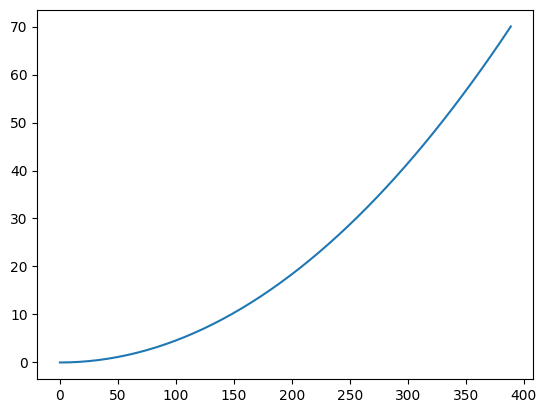

In [50]:
plt.plot(x0, z0)
plt.show()

In [51]:
q0=np.zeros(12*N)

In [52]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [53]:
h = delta_x

In [54]:
def fun1(x_int,φ,θ,ψ):
    
    def fun1_(x_int,φ,θ,ψ):
        A=mp*1/2*(1+x_int)*1/2*(1-x_int)*np.identity(3)
        B=np.zeros((3,3))
        D=1/2*(1+x_int)*1/2*(1-x_int)*I_e_rho(φ,θ,ψ)@Πe(φ,θ,ψ)
        return h/2*np.block([[A, B], [B, D]])
    
    res = np.array([fun1_(xi,φ,θ,ψ) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun2(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
    
    def fun2_(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
        A=1/h*np.identity(3)
        B=np.zeros((3,3))
        C=-1/2*(1+x_int)*S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
        return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h)),
                                                              np.asarray(me(φ1, θ1, ψ1, φ2, θ2, ψ2, h))), axis=None)
    
    res = np.array([fun2_(xi, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h) for xi in x_int])
    return np.moveaxis(res, 0, -1)

def fun3(x_int,φ,θ,ψ, dφ, dθ, dψ):
    
    def fun3_(x_int,φ,θ,ψ, dφ, dθ, dψ):
        A=np.zeros(3)
        B=1/2*(1+x_int)*I_e_rho(φ,θ,ψ)@dΠ(φ, θ, ψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun3_(xi,φ,θ,ψ, dφ, dθ, dψ) for xi in x_int])
    return np.moveaxis(res, 0, -1)

def fun4(x_int,φ,θ,ψ, dφ, dθ, dψ):
    
    def fun4_(x_int,φ,θ,ψ, dφ, dθ, dψ):
        A=np.zeros(3)   
        B=1/2*(1+x_int)*S(*(Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(φ,θ,ψ)@Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])).T
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun4_(xi,φ,θ,ψ, dφ, dθ, dψ) for xi in x_int])
    return np.moveaxis(res, 0, -1)

def fun5(x_int, li):
    
    def fun5_(x_int, li):
        B=np.zeros(3)   
        A=1/2*(1+x_int)*fe_g*li
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun5_(x, li) for x in x_int])
    return np.moveaxis(res, 0, -1)

def fun6(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
    
    def fun6_(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
        A=1/2*(1+x_int)* Ret_e_t(φ,θ,ψ)@f_t_d(dx,dy,dz)
        B=1/2*(1+x_int)* DR@ Πe(φ, θ, ψ)@  np.array([dφ, dθ, dψ])

        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun6_(xi,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ) for xi in x_int])
    return np.moveaxis(res, 0, -1)

def fun7(x_int,x,y,z):
   
    def fun7(x_int,x,y,z):
        A=1/2*(1+x_int)*sigma(x,y,z)
        B=np.zeros(3) 

        ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

        return ans
    
    res = np.array([fun7(xi,x,y,z) for xi in x_int])
    return np.moveaxis(res, 0, -1)

In [55]:
def static_solution(Q,T): 
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    f1=[]
    f2=[]
    f3=[] 
    f4=[]
    f5=[]
    f6=[]
    f7=[]
    f8=[]
    
       
    for j in range(N):

        if j == N-1:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j]), -1.0, 0.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h),-1.0,0.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 0.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 0.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5(x_int, 1), -1.0, 0.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 0.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7(x_int, x[j],y[j],z[j]), -1.0, 0.0, n=2)[0])
            f8.append(T.G(T.W, T.BO, φ[j], θ[j], T.r_g, T.r_b))
        elif j==0:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j]), 0, 1.0, n=2)[0])
            f2.append(np.zeros(6))
            f3.append(np.zeros(6))
            f4.append(np.zeros(6))
            f5.append(np.zeros(6))
            f6.append(np.zeros(6))
            f7.append(np.zeros(6))
            f8.append(np.zeros(6))
        else:    
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j]), -1.0, 1.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h),-1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0])
            f8.append(np.zeros(6))
    
    
    f1 = np.array(f1)
    f1 = np.stack(f1, axis=0)
    f2=np.vstack(f2) 
    f3=np.vstack(f3)
    f4=np.vstack(f4) 
    f5=np.vstack(f5)
    f6=np.vstack(f6) 
    f7=np.vstack(f7) 
    f8=np.vstack(f8)
    
    ddx=np.zeros(N)
    ddy=np.zeros(N)
    ddz=np.zeros(N)
    ddφ=np.zeros(N)
    ddθ=np.zeros(N)
    ddψ=np.zeros(N)
    
    for i in range(N):
        ddx[i],ddy[i],ddz[i], ddφ[i],ddθ[i],ddψ[i] =  np.linalg.solve(f1[i], 
                                                           (-f2[i]
                                                            -f3[i]
                                                            -f4[i]
                                                            -f5[i]
                                                            -f6[i]
#                                                             -f7[i]
                                                            +f8[i]
                                                   ).reshape(6,1))
  

    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    
    return ans

In [56]:
T_1 = MyTime()

In [ ]:
root_ = root(static_solution, q0, method='lm', args=(T_1,))

In [ ]:
root_

In [ ]:
x0_, z0_ = root_.x[:N], root_.x[4*N:5*N]

In [ ]:
q0 = root_.x                                         # start from static solution

In [ ]:
plt.plot(x0_, z0_, label = "Static pipelay")
plt.plot(x0, z0, label = "Catenary")
plt.legend()
plt.show()

In [ ]:
plt.plot(x0_, z0_, label = "Static pipelay")
plt.show()

### Dynamic Simulation

In [ ]:
def dynamic_func(t, Q, T):
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
        
    f1=[]
    f2=[]
    f3=[] 
    f4=[]
    f5=[]
    f6=[]
    f7=[]
    f8=[]
    
    s = np.linspace(0, 1, N)[::-1]

    for j in range(N):
    
        if j == N-1:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j]), -1.0, 0.0, n=2)[0]
                      + T.M
                     )
            f2.append(integrate.fixed_quad(lambda x_int: fun2(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h),-1.0,0.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 0.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 0.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5(x_int, 1), -1.0, 0.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 0.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7(x_int, x[j],y[j],z[j]), -1.0, 0.0, n=2)[0])
            f8.append((T.CRB(T.MRB,np.array([dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]]))
                             + T.CA(T.MA, np.array([dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]]))
                             + compute_damping(T.MRB, T.G(T.W, T.BO,φ[j],θ[j],T.r_g,T.r_b), 
                                               T.r_g, 20,100,50))@np.array([dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]]))
        elif j==0:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j]), 0, 1.0, n=2)[0])
            f2.append(np.zeros(6))
            f3.append(np.zeros(6))
            f4.append(np.zeros(6))
            f5.append(np.zeros(6))
            f6.append(np.zeros(6))
            f7.append(np.zeros(6))
            f8.append(np.zeros(6))
        else:    
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j]), -1.0, 1.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h),-1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0])
            f8.append(np.zeros(6))    
        
        if t>0.01 and j>0:
            ax=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j]))@ ne(x[j-1], y[j-1], z[j-1], φ[j-1], θ[j-1], ψ[j-1],x[j], y[j], z[j], φ[j], θ[j], ψ[j],h).T

            T.top_tension=max(T.top_tension, ax[0][0])            

            ben0=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j])) @ me( φ[j-1], θ[j-1], ψ[j-1], φ[j],θ[j],ψ[j],h).T
            ben=np.max(ben0[1:])

            I=3.14*(d0**4-dI**4)/64
            strain=np.max(ben)*d0/(2*E*I)    

            T.sagbend_strain=max(T.sagbend_strain, strain)    
    
    
    f1 = np.array(f1)
    f1 = np.stack(f1, axis=0)
    f2=np.vstack(f2) 
    f3=np.vstack(f3)
    f4=np.vstack(f4) 
    f5=np.vstack(f5)
    f6=np.vstack(f6) 
    f7=np.vstack(f7)
    f8=np.vstack(f8)
    
    ddx=np.zeros(N)
    ddy=np.zeros(N)
    ddz=np.zeros(N)
    ddφ=np.zeros(N)
    ddθ=np.zeros(N)
    ddψ=np.zeros(N)
    
    for i in range(N):
        ddx[i],ddy[i],ddz[i], ddφ[i],ddθ[i],ddψ[i] =  scipy.sparse.linalg.spsolve(scipy.sparse.csr_matrix(f1[i]), 
                                                           (
                                                            -f2[i]
                                                            -f3[i]
                                                            -f4[i]
                                                            -f5[i]
                                                            -f6[i]
#                                                             -f7[i]
                                                            +f8[i]
                                                   ).reshape(6,1))
  
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    
    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock , flush=True)
        T.wall_clock = datetime.now() 
    
    T.my_iter+=1 
    
    return ans

In [ ]:
# initial conditions correction
q0[1*N:2*N],q0[3*N:4*N],q0[5*N:6*N] = np.zeros(N), np.zeros(N), np.zeros(N)
q0[7*N:8*N],q0[9*N:10*N],q0[11*N:12*N] = np.zeros(N), np.zeros(N), np.zeros(N)
q0[6*N:7*N],q0[8*N:9*N],q0[10*N:11*N] = np.zeros(N), np.zeros(N), np.zeros(N)

In [ ]:
T_2 = MyTime()

In [ ]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func, 
                tspan, 
                q0, 
                args=(T_2, ), 
                method='RK23'
               )
print(datetime.now() - startTime1)

### Results

In [ ]:
# number of iterations
T_2.my_iter

In [ ]:
# max axial tension
T_2.top_tension

In [ ]:
# max bending strain
T_2.sagbend_strain

In [ ]:
fin=us_

In [ ]:
fin

In [ ]:
t=fin.t

In [ ]:
fin=fin.y.T

In [ ]:
t.shape, fin.shape

In [ ]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [ ]:
X,Y,Z

In [ ]:
X0,Y0,Z0

In [ ]:
us=fin.T

In [ ]:
us.shape

In [ ]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

In [ ]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

In [ ]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

In [ ]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

In [ ]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

In [ ]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

In [ ]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

In [ ]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

In [ ]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

In [ ]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

In [ ]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

In [ ]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

In [ ]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

In [ ]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

In [ ]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [ ]:
X010=us.T[:,0*N:1*N]

In [ ]:
Y010=us.T[:,2*N:3*N]

In [ ]:
Z010=us.T[:,4*N:5*N]

In [ ]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()